NOTE: Seaborn, Matplotlib ke upar banaya gaya hai — kam code mein zyada sundar, statistically-aware charts deta hai. Scatter plots do numeric variables ke beech relationship dikhane ke liye best hain (Day 47 ka correlation concept, ab visually).

1. Setup:

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/customer_churn_labeled.csv')
sns.set_style('whitegrid')   # Seaborn ka ek clean default theme

2. Basic scatter plot — Matplotlib vs Seaborn comparison:

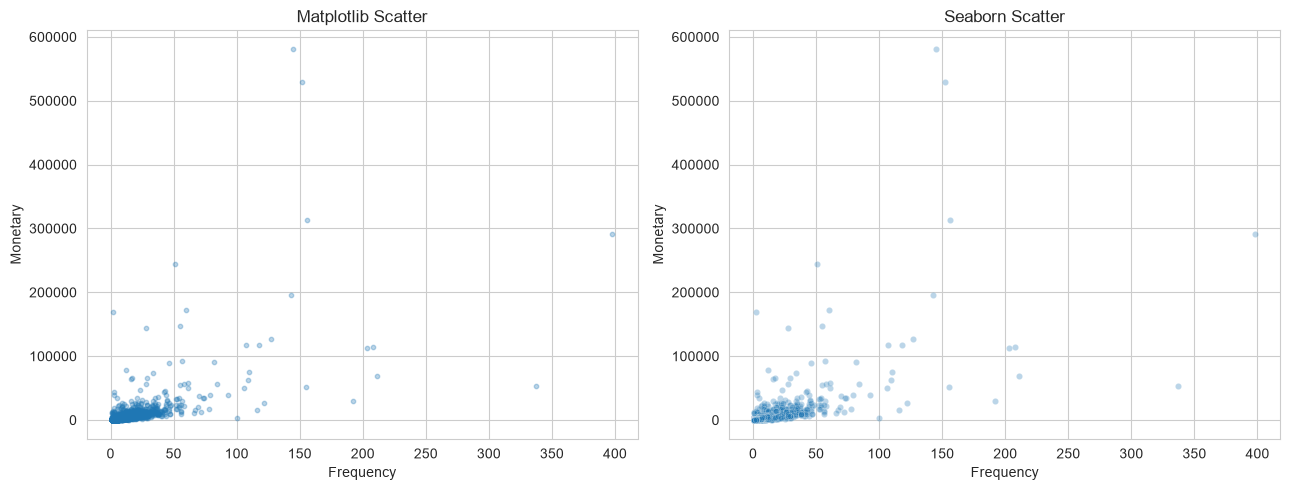

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df['Frequency'], df['Monetary'], alpha=0.3, s=10)
axes[0].set_title('Matplotlib Scatter')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Monetary')

sns.scatterplot(data=df, x='Frequency', y='Monetary', alpha=0.3, s=20, ax=axes[1])
axes[1].set_title('Seaborn Scatter')

plt.tight_layout()
plt.show()

note: Seaborn data=df, x='col1', y='col2' syntax use karta hai (DataFrame-aware), jo Matplotlib se zyada readable hai jab tum column names se directly kaam kar rahe ho.

3. hue parameter — teesra dimension add karna (color se categories dikhana, bahut powerful feature):

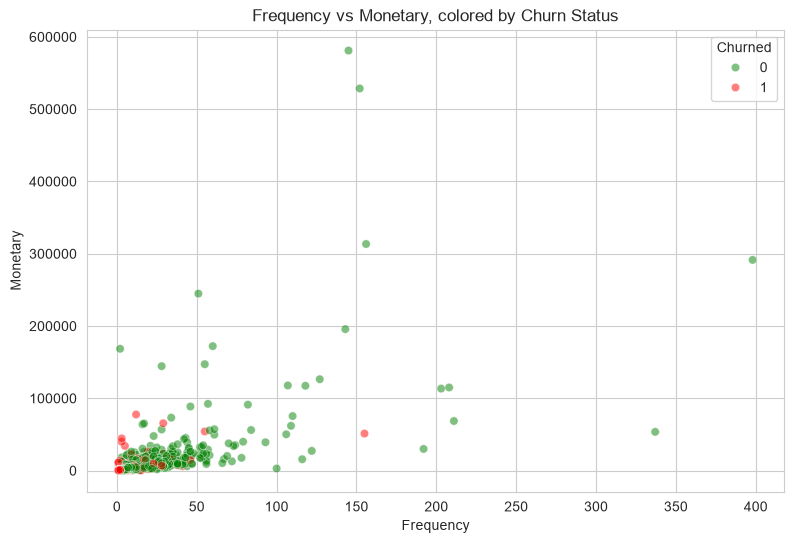

In [3]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='Frequency', y='Monetary', hue='Churned', alpha=0.5, palette={0: 'green', 1: 'red'})
plt.title('Frequency vs Monetary, colored by Churn Status')
plt.show()

Yeh bahut insightful chart hai — dekho kya churned (red) customers generally low Frequency/Monetary corner mein cluster karte hain ya random spread hain.

4. size parameter — chautha dimension bhi add kar sakte ho (point size se):

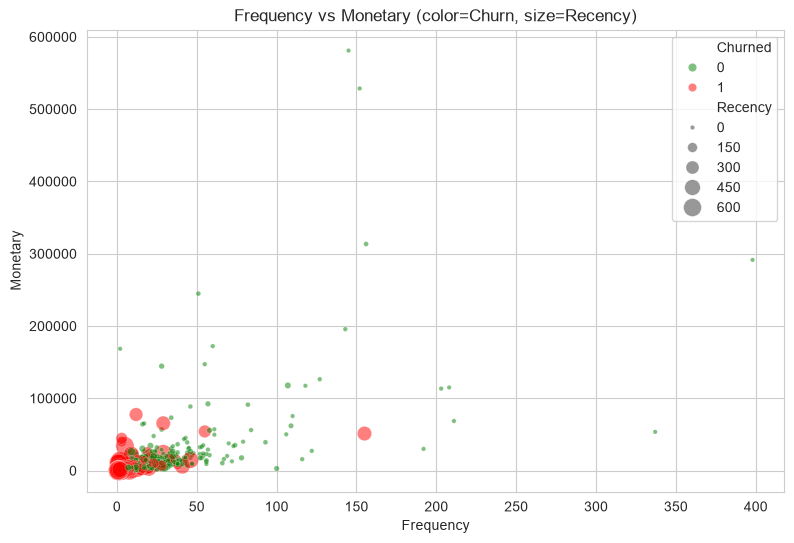

In [4]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='Frequency', y='Monetary', hue='Churned', size='Recency', 
                 sizes=(10, 200), alpha=0.5, palette={0: 'green', 1: 'red'})
plt.title('Frequency vs Monetary (color=Churn, size=Recency)')
plt.show()

5. Regression line ke saath scatter — regplot() ya lmplot() (trend dikhata hai):

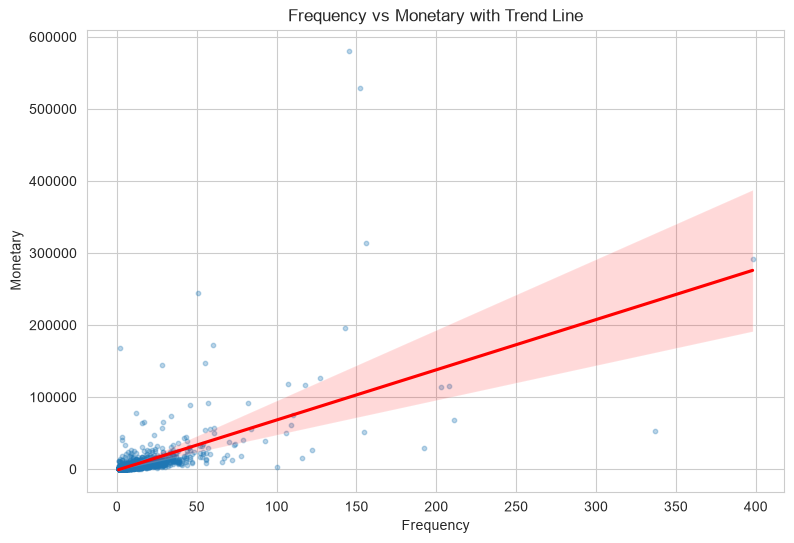

In [5]:
plt.figure(figsize=(9, 6))
sns.regplot(data=df, x='Frequency', y='Monetary', scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
plt.title('Frequency vs Monetary with Trend Line')
plt.show()

note: Yeh trend line linear regression (Month 4 ka preview) ka basic version hai — line ka slope batata hai relationship ki direction aur strength, jaisa Day 47 ka Pearson correlation number.

6. Log-scale scatter — jab data bahut skewed ho (Monetary jaisa):

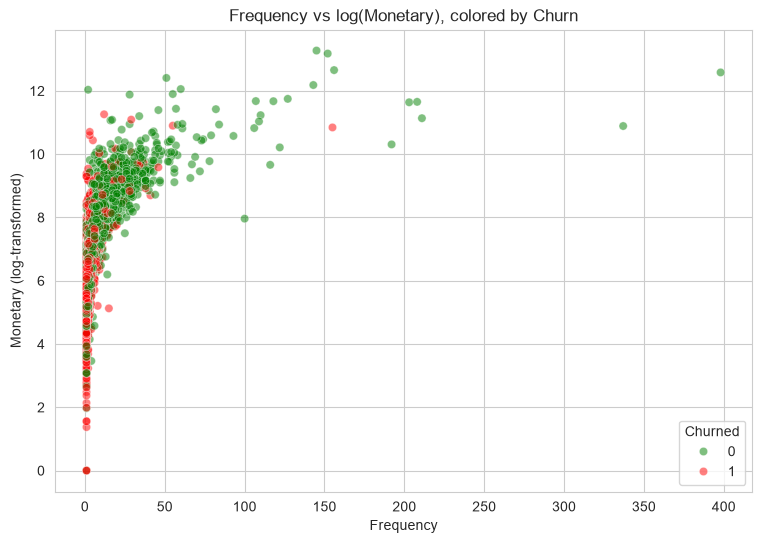

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=df, x='Frequency', y='Monetary_log', hue='Churned', alpha=0.5, palette={0: 'green', 1: 'red'}, ax=ax)
ax.set_ylabel('Monetary (log-transformed)')
ax.set_title('Frequency vs log(Monetary), colored by Churn')
plt.show()

7. Pairplot — multiple scatter plots ek saath, sabhi numeric columns ke combinations (bahut powerful EDA tool):

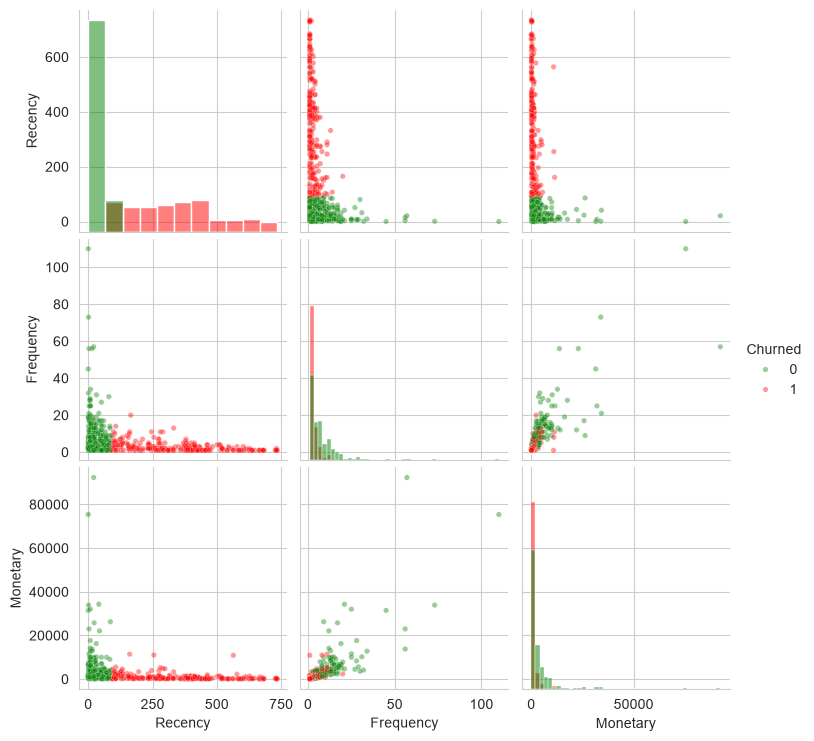

In [7]:
sample_df = df.sample(500, random_state=1)  # pura dataset slow hoga, sample lo visualization ke liye
sns.pairplot(sample_df[['Recency', 'Frequency', 'Monetary', 'Churned']], hue='Churned', 
             palette={0: 'green', 1: 'red'}, diag_kind='hist', plot_kws={'alpha': 0.4, 's': 15})
plt.show()

note: Pairplot automatically har pair ka scatter banata hai aur diagonal par har variable ka distribution (histogram) dikhata hai — ek hi command se poora EDA overview mil jaata hai.

8. Jointplot — scatter + marginal distributions ek saath:

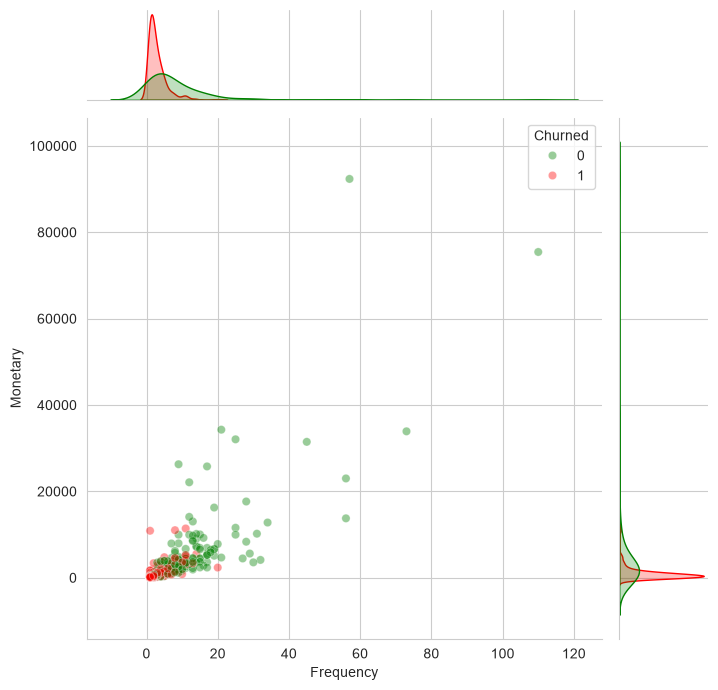

In [8]:
sns.jointplot(data=sample_df, x='Frequency', y='Monetary', hue='Churned', 
              palette={0: 'green', 1: 'red'}, alpha=0.4, height=7)
plt.show()

practice questions:

1. Recency vs Monetary ka scatter plot banao hue='Churned' ke saath — kya pattern dikhta hai?

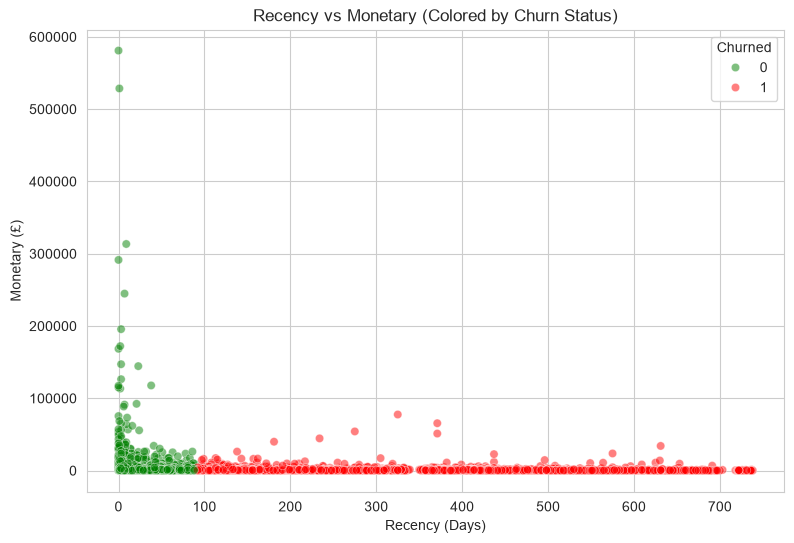

In [9]:
# Recency vs Monetary with Churn hue
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df, 
    x='Recency', 
    y='Monetary', 
    hue='Churned', 
    alpha=0.5, 
    palette={0: 'green', 1: 'red'}
)
plt.title('Recency vs Monetary (Colored by Churn Status)')
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary (£)')
plt.show()

- Pattern / Insight:
    - Red (Churned) customers zyadatar right side par cluster karenge (high Recency, yaani unko khareedari kiye bahut din ho gaye hain) aur unka Monetary value bhi low side par hoga.

    - Green (Not Churned) customers left side par zyada honge (low Recency, yaani recent buyers) aur inka Monetary spread wider hoga (kuch high value wale bhi yahin milenge).

2. sns.regplot() use karke Recency vs Frequency ka relationship dekho — trend line ka slope negative hai ya positive, aur yeh business sense banata hai kya? (Hint: zyada Recency matlab customer inactive hai, to Frequency kam honi chahiye)

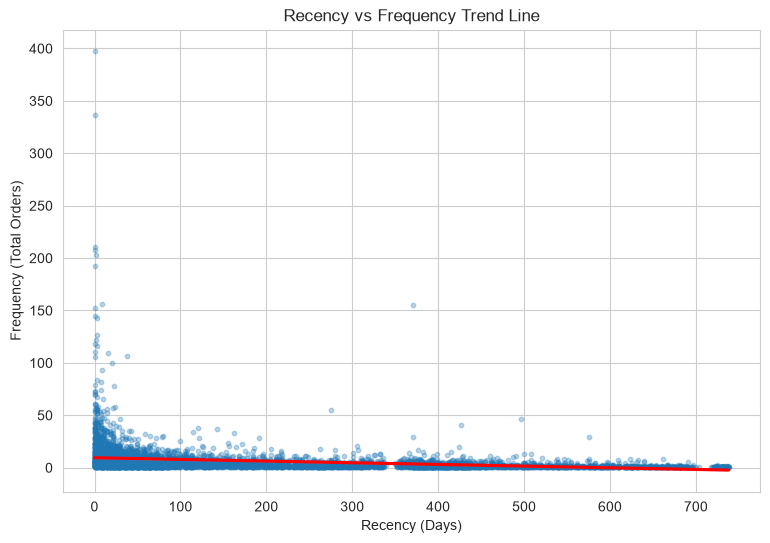

In [10]:
# Recency vs Frequency with regression line
plt.figure(figsize=(9, 6))
sns.regplot(
    data=df, 
    x='Recency', 
    y='Frequency', 
    scatter_kws={'alpha': 0.3, 's': 10}, 
    line_kws={'color': 'red'}
)
plt.title('Recency vs Frequency Trend Line')
plt.xlabel('Recency (Days)')
plt.ylabel('Frequency (Total Orders)')
plt.show()

- Slope aur Business Logic:

    - Slope Direction: Iska slope negative hoga (line up-se-neeche ki taraf jhuki hogi).

    - Business Sense: Bilkul sahi sense banata hai! Recency batati hai ki aakhri order kitne din pehle hua tha (jitna zyada number, utna purana customer), aur Frequency batati hai usne kul kitne orders diye hain. Jo customer regular aur frequent order deta hai (high frequency), woh abhi kuch din pehle hi active hoga (low recency). Iske mukable jo customer inactive ho chuka hai (high recency), uski overall frequency bhi kam hi hogi.